In [1]:
import os
os.environ.pop("CUDA_VISIBLE_DEVICES", None)
# or force it:
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA")

CUDA_VISIBLE_DEVICES: None
cuda available: True
device count: 1
NVIDIA GeForce RTX 3070 Laptop GPU


In [2]:
import os
SEED = 67


import gc
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
from datetime import datetime
from scipy import signal
from torch.utils.data import DataLoader
print("torch:", torch.__version__)
print("cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("cuda device name:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

torch.manual_seed(SEED)
from data.radar_dataset import radar_dataset

torch: 2.12.0+cu126
cuda build: 12.6
cuda available: True
cuda device count: 1
cuda device name: NVIDIA GeForce RTX 3070 Laptop GPU
cuda


In [3]:
from models.convlstm import ConvLSTM
model = ConvLSTM(input_dim=1,
                 hidden_dim=64,
                 kernel_size=(3, 3),
                 num_layers=2,
                 batch_first=True,
                 bias=True)


model = model.to(device)
model.load_state_dict(torch.load(r"C:\Users\Jacobs laptop\rainraingoaway\models\model_best_20260609_124847.pkl"))

<All keys matched successfully>

In [4]:
BATCH_SIZE =4
sample_size= 4 
dataset= radar_dataset("C:\\Users\\Jacobs laptop\\rainraingoaway\\data\\holdout\\png", list_length=sample_size, total=100)
split_idx = int(0.8 * len(dataset))

test_dataset = torch.utils.data.Subset(dataset, range(split_idx, len(dataset)))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loaded 100 images.
sample with lenth 2 created due to discontinuation in series, with change 20
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 3 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 2 created due to discontinuation in series, with change 10
sample with lenth 4 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10
sample with lenth 1 created due to discontinuation in series, with change 10


c:\Users\Jacobs laptop\rainraingoaway\src\data\data_loading.py:48: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  value= torch.from_numpy(value.to_numpy()).float()


In [5]:
import random
import numpy as np

from data.pngtojson import png_to_xy_intensity, points_to_intensity_grid

# Set seed for reproducibility
random.seed(SEED)

# Path to holdout PNG files
holdout_path = Path(r"C:\Users\Jacobs laptop\rainraingoaway\data\holdout\png")
png_files = sorted(list(holdout_path.glob("*.png")))

if not png_files:
    raise FileNotFoundError(f"No PNG files found in {holdout_path}")

# Pick a larger random selection and check the project's 0-100 intensity normalization
sample_count = min(100, len(png_files))
sample_files = random.sample(png_files, sample_count)
sample_stats = []
normalized_values = []

for file_path in sample_files:
    intensity_points = png_to_xy_intensity(str(file_path), include_zero=True)
    intensity_grid = points_to_intensity_grid(intensity_points)
    intensity_array = np.array(intensity_grid, dtype=np.float32)
    normalized_array = intensity_array / 100.0
    sample_stats.append((file_path.name, int(intensity_array.min()), int(intensity_array.max()), float(normalized_array.min()), float(normalized_array.max())))
    normalized_values.append(normalized_array.reshape(-1))

combined_normalized = np.concatenate(normalized_values)

print(f"Sampled {sample_count} random images from {holdout_path}")
for name, raw_min, raw_max, norm_min, norm_max in sample_stats:
    print(f"{name}: raw={raw_min}-{raw_max}, normalized={norm_min:.2f}-{norm_max:.2f}")

print(f"Overall normalized min across sample: {combined_normalized.min():.2f}")
print(f"Overall normalized max across sample: {combined_normalized.max():.2f}")
print(f"Overall normalized mean across sample: {combined_normalized.mean():.4f}")
print("Expected range after /100: 0.00 to 1.00")


Sampled 100 random images from C:\Users\Jacobs laptop\rainraingoaway\data\holdout\png
202606151235.png: raw=0-77, normalized=0.00-0.77
202606151325.png: raw=0-84, normalized=0.00-0.84
202606152015.png: raw=0-77, normalized=0.00-0.77
202606152135.png: raw=0-60, normalized=0.00-0.60
202606152025.png: raw=0-77, normalized=0.00-0.77
202606151700.png: raw=0-87, normalized=0.00-0.87
202606152040.png: raw=0-37, normalized=0.00-0.37
202606152205.png: raw=0-34, normalized=0.00-0.34
202606151725.png: raw=0-97, normalized=0.00-0.97
202606151525.png: raw=0-54, normalized=0.00-0.54
202606151150.png: raw=0-60, normalized=0.00-0.60
202606151450.png: raw=0-57, normalized=0.00-0.57
202606151735.png: raw=0-74, normalized=0.00-0.74
202606151140.png: raw=0-87, normalized=0.00-0.87
202606151420.png: raw=0-80, normalized=0.00-0.80
202606152055.png: raw=0-44, normalized=0.00-0.44
202606151455.png: raw=0-34, normalized=0.00-0.34
202606151335.png: raw=0-90, normalized=0.00-0.90
202606151850.png: raw=0-87, norm

c:\Users\Jacobs laptop\rainraingoaway\src\data\radar_dataset.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target, dtype=torch.float32)


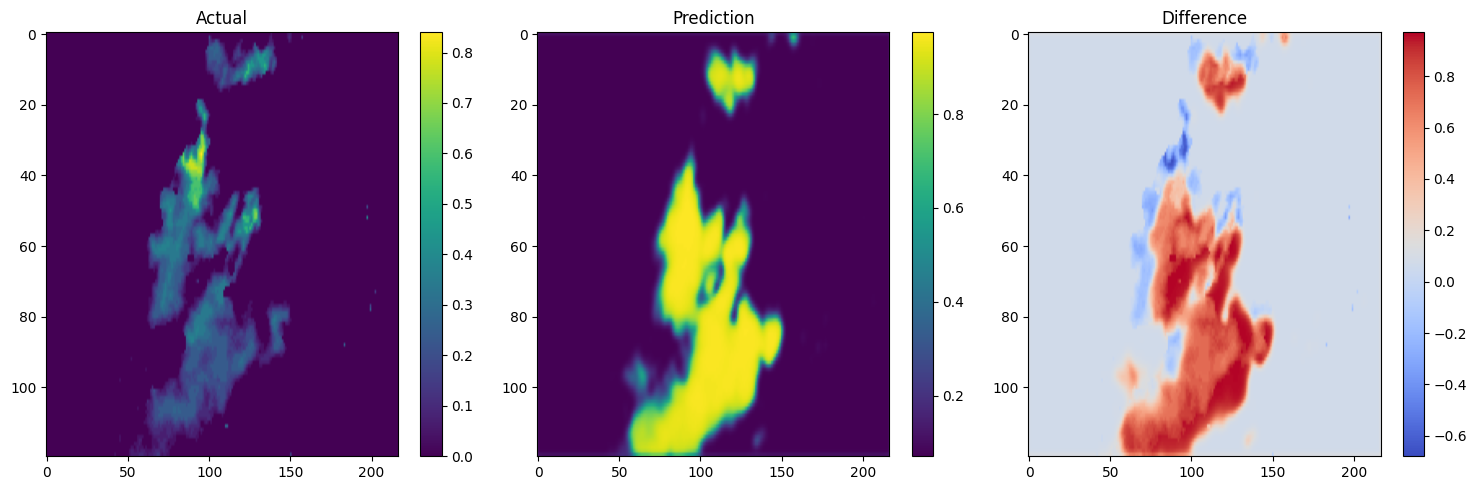

In [6]:
import matplotlib.pyplot as plt
import torch

model.eval()

# get one batch
inputs, labels = next(iter(test_loader),4)
inputs = inputs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(inputs)
sample_no=2
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto', cmap='viridis')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto', cmap='viridis')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto', cmap='coolwarm')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()

Input 1: 202606201210.png | modified 2026-06-20 12:14:03
Input 2: 202606201215.png | modified 2026-06-20 12:19:03
Input 3: 202606201220.png | modified 2026-06-20 12:24:03
Input 4: 202606201225.png | modified 2026-06-20 12:29:04


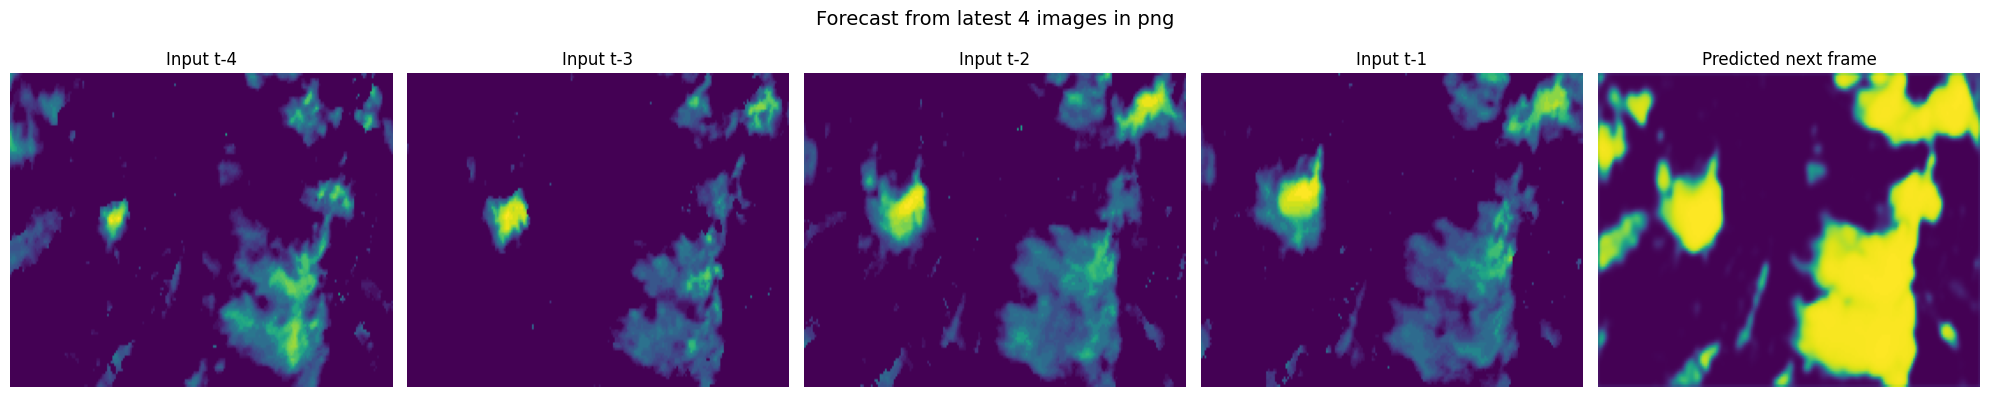

In [11]:
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from data.pngtojson import png_to_intensity_grid

model.eval()

holdout_path = Path(r"C:\Users\Jacobs laptop\rainraingoaway\data\70km\png")
png_files = sorted(holdout_path.glob("*.png"), key=lambda path: path.stat().st_mtime)

if len(png_files) < 4:
    raise ValueError("Need at least 4 PNG files to forecast the next frame.")

input_files = png_files[-4:]

for index, file_path in enumerate(input_files, start=1):
    modified_at = datetime.fromtimestamp(file_path.stat().st_mtime).isoformat(sep=' ', timespec='seconds')
    print(f'Input {index}: {file_path.name} | modified {modified_at}')

input_frames = []
for file_path in input_files:
    frame = np.array(png_to_intensity_grid(str(file_path)), dtype=np.float32) / 100.0
    input_frames.append(torch.from_numpy(frame).unsqueeze(0))

sample_inputs = torch.stack(input_frames, dim=0)
with torch.no_grad():
    sample_batch = sample_inputs.unsqueeze(0).to(device)
    sample_prediction = model(sample_batch)[0].cpu()

sample_inputs = sample_inputs.cpu()

num_steps = sample_inputs.shape[0]
fig, axes = plt.subplots(1, num_steps + 1, figsize=(4 * (num_steps + 1), 4))

for axis in axes.flat:
    axis.axis('off')

for step in range(num_steps):
    input_frame = sample_inputs[step]
    if input_frame.dim() == 3:
        input_frame = input_frame.squeeze(0)
    axes[step].imshow(input_frame.numpy(), aspect='auto', cmap='viridis')
    axes[step].set_title(f'Input t-{num_steps - step}')

pred_frame = sample_prediction.squeeze(0) if sample_prediction.dim() == 3 else sample_prediction
axes[num_steps].imshow(pred_frame.numpy(), aspect='auto', cmap='viridis')
axes[num_steps].set_title('Predicted next frame')

fig.suptitle(f'Forecast from latest 4 images in {holdout_path.name}', fontsize=14)
plt.tight_layout()
plt.show()